In [23]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [24]:
# Install dependencies (run once per environment). Comment this cell out if everything is already installed.
%pip install -q pandas numpy matplotlib seaborn librosa soundfile scikit-learn torch torchaudio torchvision tqdm kaggle ipywidgets


In [25]:
import os
import random
import zipfile
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8")
sns.set_theme(context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from pathlib import Path

PROJECT_ROOT = Path("/content")  # or Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"  # only used for artifacts/checkpoints
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_ROOT = Path("/content/drive/MyDrive/ESC-50-master")
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

SAMPLE_RATE = 22_050
TARGET_DURATION = 5.0  # seconds
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
MAX_SAMPLES = int(SAMPLE_RATE * TARGET_DURATION)

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # Windows-friendly


Using device: cpu


## 4.1 Data Pre-Processing
Menyiapkan subset ESC-50, memverifikasi metadata, dan membangun split train/val/test untuk eksperimen yang konsisten.


In [26]:
ESC50_DATASET_SLUG = "mmoreaux/environmental-sound-classification-50"


def find_esc50_root(base_dir: Path) -> Path:
    """Return the ESC-50 root folder that contains meta/esc50.csv."""
    meta_match = list(base_dir.glob("**/meta/esc50.csv"))
    if meta_match:
        return meta_match[0].parents[1]
    candidate = base_dir / "ESC-50-master"
    if candidate.exists():
        return candidate
    raise FileNotFoundError("ESC-50 folder not found. Run download_esc50().")


In [27]:
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

if not META_PATH.exists():
    raise FileNotFoundError(f"Metadata CSV not found at {META_PATH}")
if not AUDIO_DIR.exists():
    raise FileNotFoundError(f"Audio folder not found at {AUDIO_DIR}")

metadata = pd.read_csv(META_PATH)
print(f"Total clips in ESC-50: {len(metadata):,}")
metadata.head()


Total clips in ESC-50: 2,000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [28]:
SELECTED_CLASSES = [
    "helicopter",
    "chainsaw",
    "siren",
    "car_horn",
    "engine",
    "train",
    "church_bells",
    "airplane",
    "fireworks",
    "hand_saw"
]

if not (2 <= len(SELECTED_CLASSES) <= 10):
    raise ValueError("Please keep between 2 and 8 labels to satisfy the project scope.")

subset_df = metadata[metadata["category"].isin(SELECTED_CLASSES)].copy()
if subset_df.empty:
    raise ValueError("No rows match SELECTED_CLASSES. Double-check spelling against esc50.csv")

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
subset_df["target_idx"] = subset_df["category"].map(class_to_idx)

print(f"Clips kept: {len(subset_df)} across {len(SELECTED_CLASSES)} classes")
class_counts = subset_df["category"].value_counts().loc[SELECTED_CLASSES]
class_counts


Clips kept: 400 across 10 classes


,count
category,
helicopter,40
chainsaw,40
siren,40
car_horn,40
engine,40
train,40
church_bells,40
airplane,40
fireworks,40


## 4.2 Feature Extraction
Transformasi sinyal audio ke mel-spectrogram, normalisasi, dan augmentasi ringan sebelum masuk ke model.


In [29]:
def pad_or_trim(signal: np.ndarray, max_samples: int = MAX_SAMPLES) -> np.ndarray:
    if len(signal) > max_samples:
        return signal[:max_samples]
    if len(signal) < max_samples:
        pad_width = max_samples - len(signal)
        signal = np.pad(signal, (0, pad_width), mode="constant")
    return signal


def waveform_to_mel(signal: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=sr // 2,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


def normalize_mel(mel_db: np.ndarray) -> np.ndarray:
    mean = mel_db.mean()
    std = mel_db.std()
    return (mel_db - mean) / (std + 1e-6)


def random_time_shift(signal: np.ndarray, max_shift: int = 2_000) -> np.ndarray:
    if max_shift <= 0:
        return signal
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift)



In [30]:
class Esc50MelDataset(Dataset):
    def __init__(self, df: pd.DataFrame, audio_dir: Path, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        file_path = self.audio_dir / row["filename"]
        signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)

        if self.augment:
            signal = random_time_shift(signal)

        signal = pad_or_trim(signal)
        mel = waveform_to_mel(signal)
        mel = normalize_mel(mel)

        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row["target_idx"], dtype=torch.long)

        return {
            "input": mel_tensor,
            "label": label,
            "category": row["category"],
            "filename": row["filename"],
        }



In [31]:
train_df, temp_df = train_test_split(
    subset_df,
    test_size=0.3,
    stratify=subset_df["category"],
    random_state=RANDOM_SEED,
)
val_df, _ = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["category"],
    random_state=RANDOM_SEED,
)

print(
    f"Train: {len(train_df)}, Val: {len(val_df)} (test loaded from Drive folder below)"
)

train_dataset = Esc50MelDataset(train_df, AUDIO_DIR, augment=True)
val_dataset = Esc50MelDataset(val_df, AUDIO_DIR, augment=False)

common_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(train_dataset, shuffle=True, **common_loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)



Train: 280, Val: 60 (test loaded from Drive folder below)


## 4.3 Visualisasi
Eksplorasi visual untuk distribusi data, contoh mel-spectrogram, dan metrik training.


/tmp/ipython-input-3720035113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


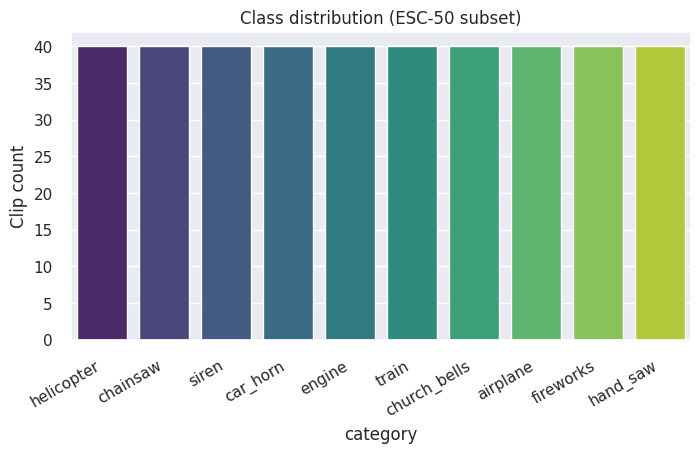

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Clip count")
plt.title("Class distribution (ESC-50 subset)")
plt.show()


In [33]:
# Build test set from the shared Drive folder (class subfolders with wav files)
TEST_AUDIO_ROOT = Path("/content/drive/MyDrive/ESC-50-master/data test")
# If you added the folder into MyDrive instead of Shared drives, change to:
# TEST_AUDIO_ROOT = Path("/content/drive/MyDrive/data test")


def build_test_df_from_folder(root: Path, selected_classes: List[str]) -> pd.DataFrame:
    rows: List[Dict[str, str]] = []
    root = Path(root)
    for cls in selected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing folder for class '{cls}': {cls_dir}")
            continue
        for audio_path in cls_dir.glob("*.wav"):
            rows.append({
                "filename": f"{cls}/{audio_path.name}",
                "category": cls,
            })
    if not rows:
        raise ValueError(f"No audio files found under {root}. Check the mount/path.")
    df = pd.DataFrame(rows)
    df["target_idx"] = df["category"].map(class_to_idx)
    return df


external_test_df = build_test_df_from_folder(TEST_AUDIO_ROOT, SELECTED_CLASSES)
print(f"External test clips found: {len(external_test_df)}")

# Override test split to use the external clips
test_df = external_test_df

test_dataset = Esc50MelDataset(test_df, TEST_AUDIO_ROOT, augment=False)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)


External test clips found: 80


Batch mel shape: torch.Size([32, 1, 128, 216])
Batch labels shape: torch.Size([32])


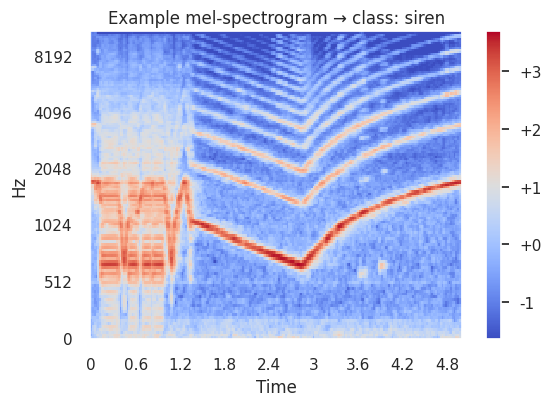

In [34]:
sample_batch = next(iter(train_loader))
inputs = sample_batch["input"]
labels = sample_batch["label"]
print(f"Batch mel shape: {inputs.shape}")
print(f"Batch labels shape: {labels.shape}")

idx = 0
mel_img = inputs[idx, 0].numpy()
plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_img, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title(f"Example mel-spectrogram → class: {idx_to_class[labels[idx].item()]}")
plt.colorbar(format="%+2.0f")
plt.show()


## 4.4 Modelling
Mendefinisikan arsitektur CNN berbasis mel-spectrogram serta proses training dan evaluasinya.


### 4.4.1 Arsitektur
Blok konvolusi berulang untuk mengekstrak pola frekuensi sebelum klasifikasi linear.


In [35]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, pool_size: Tuple[int, int] = (2, 2), dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SoundClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(1, 16, dropout=0.1),
            ConvBlock(16, 32, dropout=0.15),
            ConvBlock(32, 64, dropout=0.2),
            ConvBlock(64, 128, pool_size=(2, 1), dropout=0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        return self.classifier(x)


model = SoundClassifier(num_classes=len(SELECTED_CLASSES)).to(device)
print(model)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")


SoundClassifier(
  (feature_extractor): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (

### 4.4.2 Training
Fungsi loop epoch, optimisasi, dan eksekusi training utama.


In [36]:
from copy import deepcopy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> Tuple[float, float]:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        inputs = batch["input"].to(device)
        labels = batch["label"].to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train_model(model: nn.Module, epochs: int = EPOCHS) -> Dict[str, List[float]]:
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            print(f"→ New best val_acc: {best_val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with val_acc={best_val_acc:.3f}")

    return history



In [37]:
%%time
history = train_model(model, epochs=EPOCHS)


Epoch 1/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

→ New best val_acc: 0.100
Epoch 2/30


  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 30/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Loaded best model with val_acc=0.900
CPU times: user 17min 35s, sys: 1min 22s, total: 18min 58s
Wall time: 16min 47s


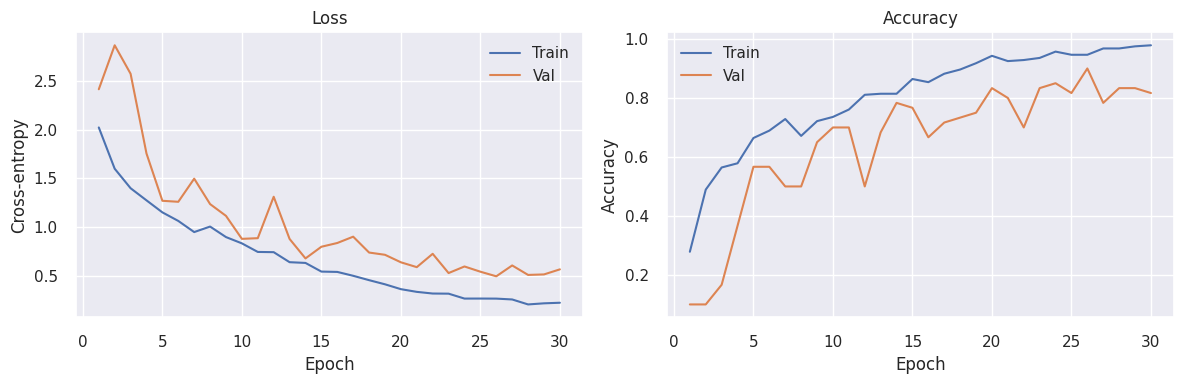

In [38]:
def plot_history(history: Dict[str, List[float]]):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["val_acc"], label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history)


### 4.4.3 Evaluasi
Evaluasi model dengan pendekatan chunking untuk audio berdurasi bervariasi.


In [39]:
# === Chunked inference over variable-length test audio (wav/mp3/m4a) ===

AUDIO_EXTENSIONS = (".wav", ".mp3", ".m4a")


def iter_test_files_from_folder(root: Path, selected_classes: List[str]):
    """Yield metadata dicts for all supported audio files under class subfolders."""
    root = Path(root)
    for cls in selected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing folder for class '{cls}': {cls_dir}")
            continue
        for audio_path in cls_dir.iterdir():
            if not audio_path.is_file():
                continue
            if audio_path.suffix.lower() not in AUDIO_EXTENSIONS:
                continue
            yield {
                "filepath": audio_path,
                "filename": f"{cls}/{audio_path.name}",
                "category": cls,
                "target_idx": class_to_idx[cls],
            }


def chunk_signal(
    signal: np.ndarray,
    sr: int = SAMPLE_RATE,
    chunk_duration: float = TARGET_DURATION,
    overlap: float = 0.5,
) -> List[np.ndarray]:
    """Split signal into overlapping chunks of fixed duration.

    Returns a list of 1D numpy arrays, each at most MAX_SAMPLES long.
    """
    max_samples = int(sr * chunk_duration)
    if max_samples <= 0:
        return [signal]

    if len(signal) <= max_samples:
        return [pad_or_trim(signal, max_samples)]

    step = int(max_samples * (1.0 - overlap))
    step = max(1, min(step, max_samples))

    chunks: List[np.ndarray] = []
    start = 0
    end_limit = len(signal) - max_samples
    while start <= end_limit:
        chunk = signal[start : start + max_samples]
        chunks.append(chunk)
        start += step

    # Ensure we include the tail of the clip
    if end_limit > 0 and (len(signal) - max_samples) not in range(0, start, step):
        tail_start = len(signal) - max_samples
        chunks.append(signal[tail_start : tail_start + max_samples])

    return [pad_or_trim(c, max_samples) for c in chunks]



def collect_predictions_chunked(
    model: nn.Module,
    root: Path,
    selected_classes: List[str],
    overlap: float = 0.5,
):
    """Run chunked inference over all audio files in the given folder tree.

    For each file we:
      - load the full waveform
      - split into overlapping 5-second chunks
      - classify each chunk
      - average the softmax probabilities across chunks
    """
    model.eval()

    y_true, y_pred, y_prob = [], [], []
    filenames, categories = [], []

    with torch.no_grad():
        for item in tqdm(
            list(iter_test_files_from_folder(root, selected_classes)),
            desc="Evaluating (chunked)",
        ):
            audio_path: Path = item["filepath"]
            try:
                signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
            except Exception as e:
                print(f"Error loading {audio_path}: {e}")
                continue

            chunks = chunk_signal(
                signal,
                sr=SAMPLE_RATE,
                chunk_duration=TARGET_DURATION,
                overlap=overlap,
            )
            if not chunks:
                continue

            mel_batch = []
            for sig in chunks:
                mel = waveform_to_mel(sig)
                mel = normalize_mel(mel)
                mel_batch.append(mel)

            mel_batch = np.stack(mel_batch, axis=0)  # [num_chunks, n_mels, time]
            inputs = (
                torch.tensor(mel_batch, dtype=torch.float32)
                .unsqueeze(1)
                .to(device)
            )

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)  # [num_chunks, n_classes]
            mean_probs = probs.mean(dim=0)  # [n_classes]
            pred = mean_probs.argmax().item()

            y_true.append(item["target_idx"])
            y_pred.append(pred)
            y_prob.append(mean_probs.cpu().numpy())
            filenames.append(item["filename"])
            categories.append(item["category"])

    return (
        np.array(y_true),
        np.array(y_pred),
        np.vstack(y_prob) if y_prob else np.empty((0, len(SELECTED_CLASSES))),
        filenames,
        categories,
    )


# Run chunked evaluation on the external test folder (supports wav/mp3/m4a)
(
    y_true_chunk,
    y_pred_chunk,
    y_prob_chunk,
    test_files_chunk,
    test_categories_chunk,
) = collect_predictions_chunked(
    model,
    TEST_AUDIO_ROOT,
    SELECTED_CLASSES,
    overlap=0.5,
)

if len(y_true_chunk) > 0:
    test_acc_chunk = (y_true_chunk == y_pred_chunk).mean()
else:
    test_acc_chunk = float("nan")

print(f"Chunked test accuracy: {test_acc_chunk:.3f}")
print(
    classification_report(
        y_true_chunk,
        y_pred_chunk,
        target_names=SELECTED_CLASSES,
        digits=4,
    )
)


Evaluating (chunked):   0%|          | 0/91 [00:00<?, ?it/s]

/tmp/ipython-input-2361815531.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-2361815531.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Chunked test accuracy: 0.659
              precision    recall  f1-score   support

  helicopter     0.5455    0.6000    0.5714        10
    chainsaw     0.7000    0.8750    0.7778         8
       siren     0.7500    0.6000    0.6667        10
    car_horn     0.8889    0.8889    0.8889         9
      engine     0.0000    0.0000    0.0000         5
       train     0.5556    0.5000    0.5263        10
church_bells     0.8000    0.8000    0.8000        10
    airplane     0.2308    0.3333    0.2727         9
   fireworks     0.9091    1.0000    0.9524        10
    hand_saw     1.0000    0.7000    0.8235        10

    accuracy                         0.6593        91
   macro avg     0.6380    0.6297    0.6280        91
weighted avg     0.6734    0.6593    0.6602        91



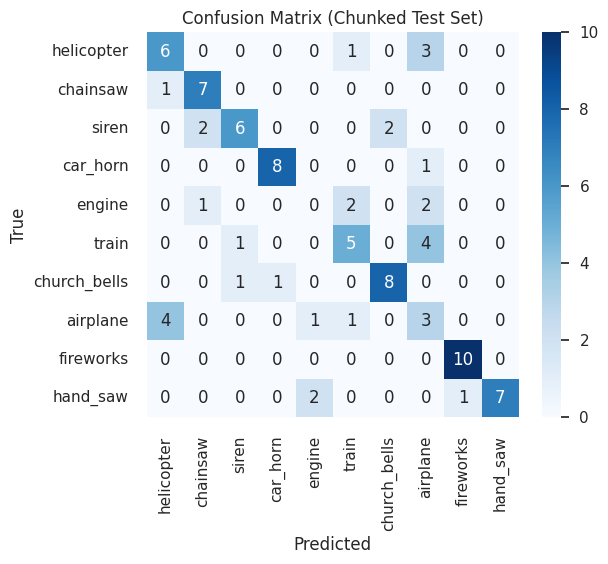

In [40]:
if len(y_true_chunk) == 0:
    print("No chunked predictions available to plot.")
else:
    cm = confusion_matrix(y_true_chunk, y_pred_chunk)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SELECTED_CLASSES,
        yticklabels=SELECTED_CLASSES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Chunked Test Set)")
    plt.show()


File: engine/Lotus Renault Engine Sound 🤤 #shorts #f1 #formula1.wav
True label: engine
Predicted: airplane (49.55%)


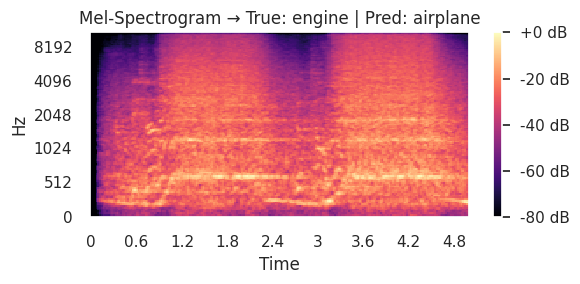

,class,probability
7,airplane,0.495453
1,chainsaw,0.301041
0,helicopter,0.068511
3,car_horn,0.063351
4,engine,0.022928
8,fireworks,0.014242
5,train,0.013595
6,church_bells,0.008860
2,siren,0.007942
9,hand_saw,0.004077


------------------------------------------------------------
File: helicopter/Helicopter Sound Effect.wav
True label: helicopter
Predicted: car_horn (40.87%)


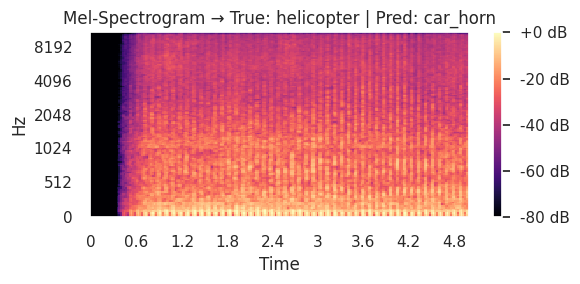

,class,probability
3,car_horn,0.408667
0,helicopter,0.209308
7,airplane,0.157459
1,chainsaw,0.139740
8,fireworks,0.056169
5,train,0.013645
4,engine,0.011374
6,church_bells,0.001968
2,siren,0.000885
9,hand_saw,0.000786


------------------------------------------------------------
File: siren/Siren 5.wav
True label: siren
Predicted: church_bells (34.65%)


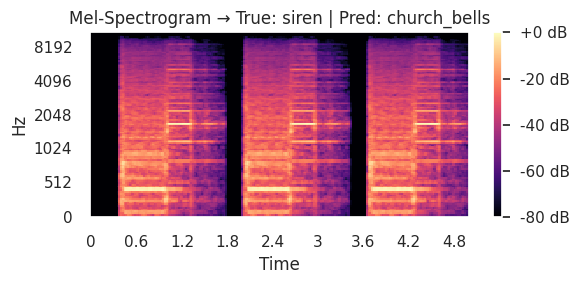

,class,probability
6,church_bells,0.346540
1,chainsaw,0.328895
3,car_horn,0.142319
9,hand_saw,0.058768
8,fireworks,0.053549
2,siren,0.053262
7,airplane,0.006196
4,engine,0.005340
5,train,0.003536
0,helicopter,0.001595


------------------------------------------------------------


In [41]:
def predict_clip(model: nn.Module, file_path: Path) -> Tuple[str, float, np.ndarray]:
    signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = pad_or_trim(signal)
    mel = waveform_to_mel(signal)
    mel = normalize_mel(mel)
    tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    return idx_to_class[pred_idx], probs[pred_idx], probs


def show_sample_predictions(num_samples: int = 4):
    samples = test_df.sample(num_samples, random_state=RANDOM_SEED)
    for _, row in samples.iterrows():
        file_path = TEST_AUDIO_ROOT / row["filename"]
        pred_label, pred_conf, probs = predict_clip(model, file_path)
        true_label = row["category"]

        print(f"File: {row['filename']}")
        print(f"True label: {true_label}")
        print(f"Predicted: {pred_label} ({pred_conf:.2%})")

        plt.figure(figsize=(6, 3))
        mel = waveform_to_mel(pad_or_trim(librosa.load(file_path, sr=SAMPLE_RATE)[0]))
        librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
        plt.title(f"Mel-Spectrogram → True: {true_label} | Pred: {pred_label}")
        plt.colorbar(format="%+2.0f dB")
        plt.tight_layout()
        plt.show()

        prob_df = pd.DataFrame({"class": SELECTED_CLASSES, "probability": probs})
        prob_df = prob_df.sort_values("probability", ascending=False)
        display(prob_df)
        print("-" * 60)


show_sample_predictions(num_samples=3)
